# Maskininlärning
## Students Social Media Addiction

> #### Setup

In [163]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

import joblib

In [128]:
data = pd.read_csv("data/Students Social Media Addiction.csv")

> ##### Från EDA

In [129]:
selected_data = data.drop(["Student_ID", "Country", "Most_Used_Platform", "Gender", "Age"], axis=1)

In [130]:
selected_data["Academic_Level"] = pd.Categorical(selected_data.Academic_Level, categories=["High School", "Undergraduate", "Graduate"], ordered=True)

selected_data["Academic_Level_Nr"] = selected_data.Academic_Level.cat.codes

selected_data = selected_data.drop("Academic_Level", axis=1)

In [131]:
selected_data["Affects_Academic_Performance"] = pd.Categorical(selected_data.Affects_Academic_Performance, categories=["No", "Yes"], ordered=True)

In [132]:
selected_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 705 entries, 0 to 704
Data columns (total 8 columns):
 #   Column                        Non-Null Count  Dtype   
---  ------                        --------------  -----   
 0   Avg_Daily_Usage_Hours         705 non-null    float64 
 1   Affects_Academic_Performance  705 non-null    category
 2   Sleep_Hours_Per_Night         705 non-null    float64 
 3   Mental_Health_Score           705 non-null    int64   
 4   Relationship_Status           705 non-null    object  
 5   Conflicts_Over_Social_Media   705 non-null    int64   
 6   Addicted_Score                705 non-null    int64   
 7   Academic_Level_Nr             705 non-null    int8    
dtypes: category(1), float64(2), int64(3), int8(1), object(1)
memory usage: 34.7+ KB


> ##### Inför ML

In [133]:
X = selected_data.drop(columns="Affects_Academic_Performance")
y = selected_data["Affects_Academic_Performance"]

In [134]:
X = pd.get_dummies(X, dtype=int)
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 705 entries, 0 to 704
Data columns (total 9 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Avg_Daily_Usage_Hours                705 non-null    float64
 1   Sleep_Hours_Per_Night                705 non-null    float64
 2   Mental_Health_Score                  705 non-null    int64  
 3   Conflicts_Over_Social_Media          705 non-null    int64  
 4   Addicted_Score                       705 non-null    int64  
 5   Academic_Level_Nr                    705 non-null    int8   
 6   Relationship_Status_Complicated      705 non-null    int64  
 7   Relationship_Status_In Relationship  705 non-null    int64  
 8   Relationship_Status_Single           705 non-null    int64  
dtypes: float64(2), int64(6), int8(1)
memory usage: 44.9 KB


In [135]:
y.info()

<class 'pandas.core.series.Series'>
RangeIndex: 705 entries, 0 to 704
Series name: Affects_Academic_Performance
Non-Null Count  Dtype   
--------------  -----   
705 non-null    category
dtypes: category(1)
memory usage: 961.0 bytes


In [137]:
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.25, random_state=42)

> ### ML

In [138]:
model_svc = make_pipeline(
  StandardScaler(), 
  SVC(random_state=42)
)

svc_hyperparams = {
  "svc__kernel": ["linear", "rbf", "poly", "sigmoid"],
  "svc__C": [0.1, 1, 10],
  "svc__gamma": [0.01, 0.1, 1]
}

model_svc_gs = GridSearchCV(model_svc, svc_hyperparams, cv=5, scoring="accuracy")

model_svc_gs.fit(X_train, y_train)

y_pred_svc = model_svc_gs.predict(X_val)

print("Accuracy:", accuracy_score(y_val, y_pred_svc))
print("Hyperparameters:", model_svc_gs.best_params_)
print(classification_report(y_val, y_pred_svc))

Accuracy: 0.9929078014184397
Hyperparameters: {'svc__C': 0.1, 'svc__gamma': 0.01, 'svc__kernel': 'linear'}
              precision    recall  f1-score   support

          No       0.98      1.00      0.99        51
         Yes       1.00      0.99      0.99        90

    accuracy                           0.99       141
   macro avg       0.99      0.99      0.99       141
weighted avg       0.99      0.99      0.99       141



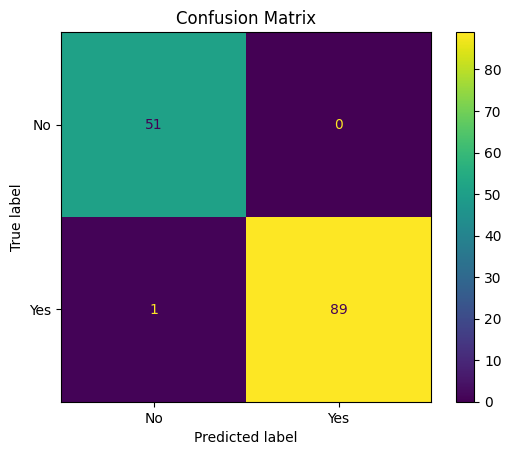

In [153]:
cm_svc = confusion_matrix(y_val, y_pred_svc)

cm_svc_display = ConfusionMatrixDisplay(confusion_matrix=cm_svc, display_labels=["No", "Yes"])
cm_svc_display.plot()
plt.title("Confusion Matrix")
plt.show()

>> SVC har gjort en felgissning. 

In [159]:
model_rf = make_pipeline(
  StandardScaler(),
  RandomForestClassifier(random_state=42)
)

rf_hyperparams = {
  "randomforestclassifier__n_estimators": [50, 75, 100],
  "randomforestclassifier__max_depth": [3, 5, 7, None]
}

model_rf_gs = GridSearchCV(model_rf, rf_hyperparams, cv=5, scoring="accuracy")

model_rf_gs.fit(X_train, y_train)

y_pred_rf = model_rf_gs.predict(X_val)

print("Accuracy:", accuracy_score(y_val, y_pred_rf))
print("Hyperparameters:", model_rf_gs.best_params_)
print(classification_report(y_val, y_pred_rf))

Accuracy: 1.0
Hyperparameters: {'randomforestclassifier__max_depth': 5, 'randomforestclassifier__n_estimators': 50}
              precision    recall  f1-score   support

          No       1.00      1.00      1.00        51
         Yes       1.00      1.00      1.00        90

    accuracy                           1.00       141
   macro avg       1.00      1.00      1.00       141
weighted avg       1.00      1.00      1.00       141



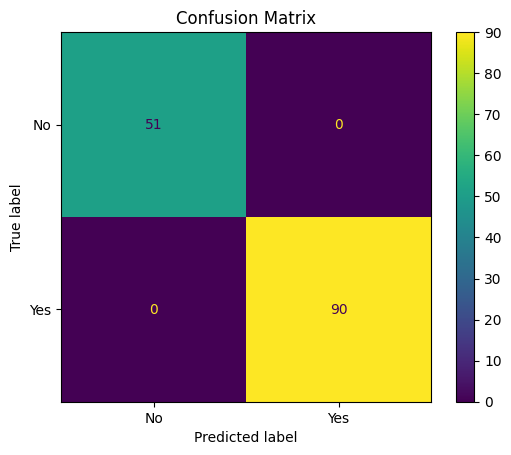

In [155]:
cm_rf = confusion_matrix(y_val, y_pred_rf)

cm_rf_display = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=["No", "Yes"])
cm_rf_display.plot()
plt.title("Confusion Matrix")
plt.show()

>> Random forest har fått 100% rätt. 

> #### Träna om den bästa modellen och testa på testdata

In [160]:
model_rf_gs.fit(X_train_full, y_train_full)

y_pred_rf_full = model_rf_gs.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf_full))
print(classification_report(y_test, y_pred_rf_full))

Accuracy: 1.0
              precision    recall  f1-score   support

          No       1.00      1.00      1.00        54
         Yes       1.00      1.00      1.00        87

    accuracy                           1.00       141
   macro avg       1.00      1.00      1.00       141
weighted avg       1.00      1.00      1.00       141



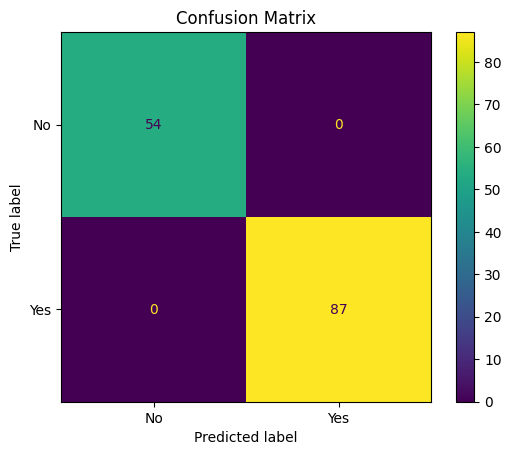

In [161]:
cm_rf_full = confusion_matrix(y_test, y_pred_rf_full)

cm_rf_full_display = ConfusionMatrixDisplay(confusion_matrix=cm_rf_full, display_labels=["No", "Yes"])
cm_rf_full_display.plot()
plt.title("Confusion Matrix")
plt.show()


>> Även efter att modellen tränats om och testats på testdatan så har den 100% rätt. 

> #### Träna om modellen på hela datasetet och spara modellen

In [162]:
model_rf_gs.fit(X, y)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'randomforestclassifier__max_depth': [3, 5, ...], 'randomforestclassifier__n_estimators': [50, 75, ...]}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [164]:
joblib.dump(model_rf_gs, "best_rf_model.pkl")
print("Model Saved!")

Model Saved!


>> Modellen är sparad för framtida bruk.